In [2]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [14]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
)
from src.plotting import (
    make_animation,
    plot
)
import plotly.express as px
from dotenv import load_dotenv

In [4]:
model = "bruss"
ds_id = "final"
ds, output_dir = get_dataset(model, ds_id, "SCRATCHDIR")
df = ds.df
df["ratio_b_a"] = df["B"] / df["A"]
df["ratio_d"] = df["Dv"] / df["Du"]

In [5]:
fig = px.scatter_3d(
    df,
    x="A",
    y="ratio_b_a",
    z="rel_std_u", 
    color="pca_label", 
    hover_data={"idx": True},
    color_continuous_scale=px.colors.sequential.Bluered,
)
fig.update_traces(marker_size=5)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [12]:
df['pattern_class'].unique()

array([0, 2, 1])

2.6107378 2.4014137306320076


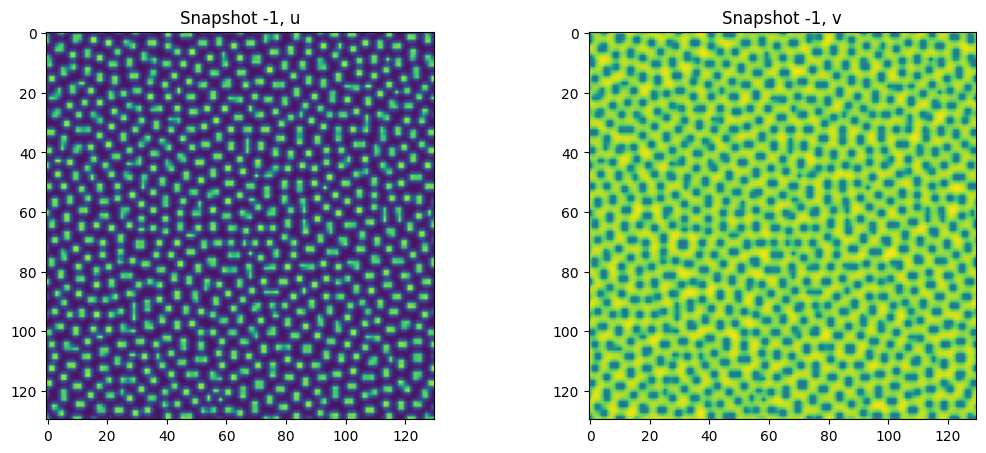

2.633109 2.884584724749336


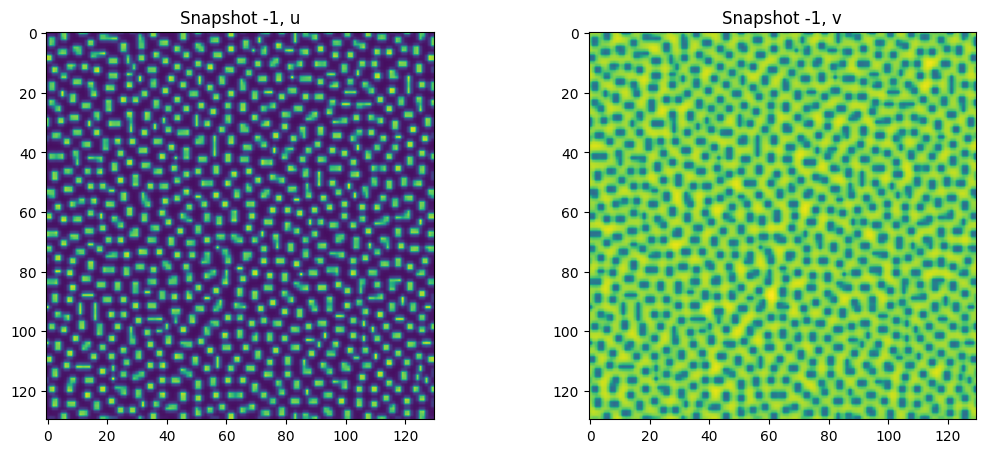

4.0066395 2.022866294808904


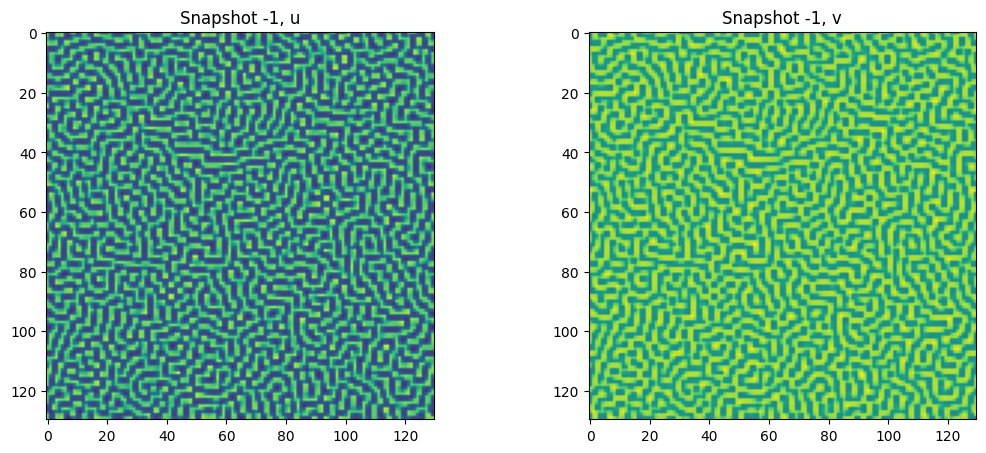

4.13255 1.3655981415832839


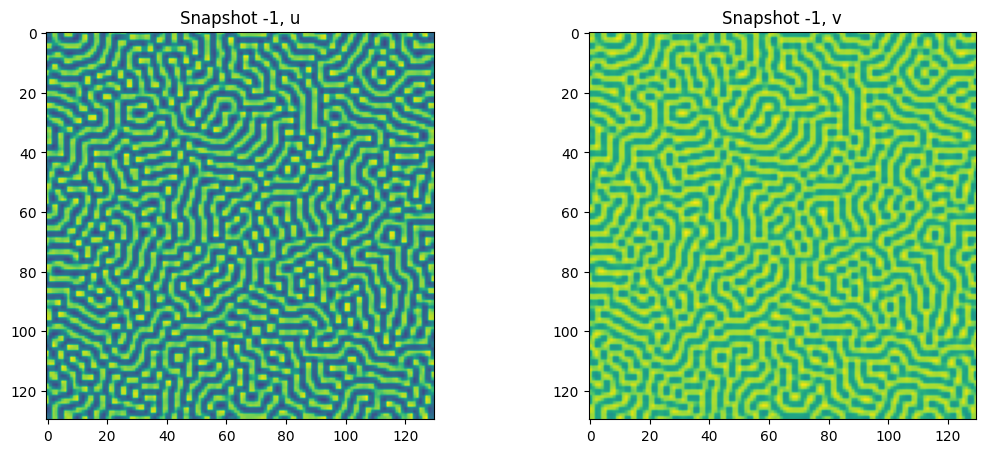

3.6003366 1.5133118386764173


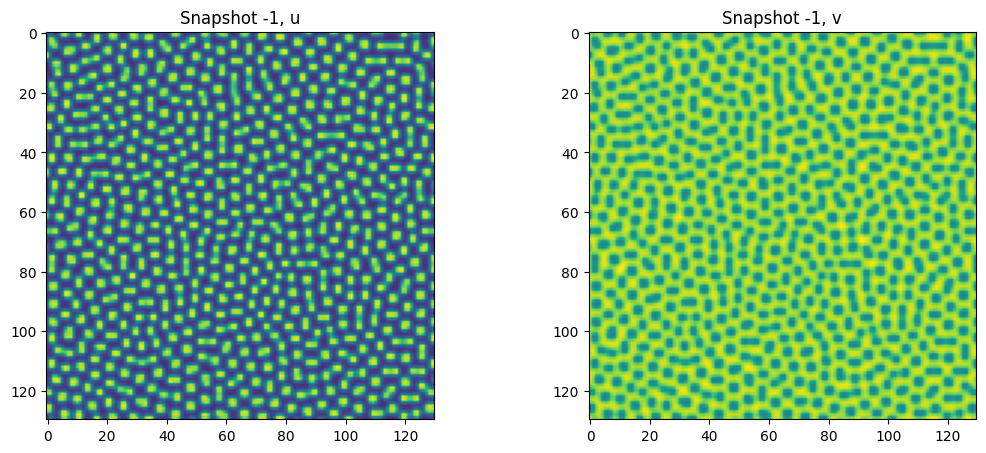

In [21]:
df_sub = df[df.pca_label == 1]
for i, row in df_sub.sample(5).iterrows():
    d = ds.get_data(i)
    print(row["A"], row["ratio_b_a"], flush=True)
    plot(d, 0, np.max(d))
    plt.show()

In [ ]:
indices = [102, 1104, 1814, 2547, 3365, 3466, 6760, 7333, 7698, 9312, 9520, 10686]
df_sel = df.iloc[indices]

<Axes: xlabel='ratio_b_a', ylabel='A'>

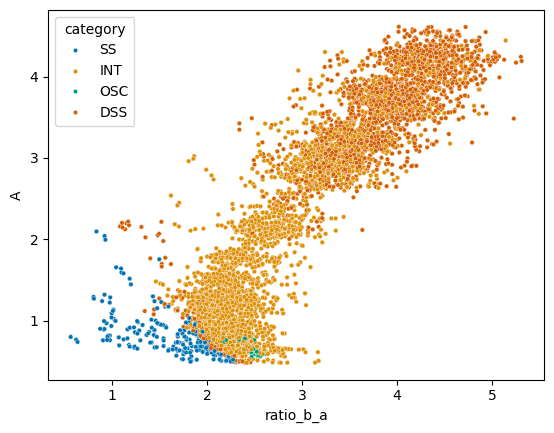

In [ ]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="A", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
